# Partie 1 — Exploration & Prétraitement des Données
## Détection de Tweets Suspects
**Auteur :** TRAORE KARIM  
**Date :** 2026  
**Encadrant :** Dr. Abdoul Kader KABORE

---
Ce notebook couvre :
1. Chargement et inspection du dataset
2. Analyse exploratoire (EDA)
3. Visualisations
4. Prétraitement du texte
5. Sauvegarde des données nettoyées

## 0. Installation des dépendances

In [41]:
!python --version

Python 3.14.3


In [42]:
# Installer les librairies nécessaires (à exécuter une seule fois)
import sys
!{sys.executable} -m pip install pandas numpy matplotlib seaborn wordcloud nltk scikit-learn


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Imports

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from wordcloud import WordCloud

import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from collections import Counter

import warnings
warnings.filterwarnings('ignore')

# Téléchargement des ressources NLTK
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('omw-1.4')

# Style des graphiques
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print('✅ Imports OK')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...


✅ Imports OK


[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


## 2. Chargement des données

In [44]:
# -------------------------------------------------------
# Adapter le chemin selon ton fichier téléchargé depuis
# https://drive.google.com/file/d/1US0luOWPOeVPpUQnpyxr41zrBmeg4Gjk
# -------------------------------------------------------
DATA_PATH = r'C:\Users\user\Desktop\Mon projet de Detection de suspect\data\raw\tweets_suspect.csv'

df = pd.read_csv(DATA_PATH)
print(f'Shape : {df.shape}')
df.head(15)

Shape : (60000, 2)


,message,label
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",1
1,is upset that he can't update his Facebook by ...,1
2,@Kenichan I dived many times for the ball. Man...,1
3,my whole body feels itchy and like its on fire,0
4,"@nationwideclass no, it's not behaving at all....",1
5,@Kwesidei not the whole crew,1
6,Need a hug,1
7,@LOLTrish hey long time no see! Yes.. Rains a...,1
8,@Tatiana_K nope they didn't have it,1
9,@twittera que me muera ?,1


## 3. Inspection générale

In [45]:
print('=== Informations générales ===')
df.info()
print()
print('=== Types de colonnes ===')
print(df.dtypes)
print()
print('=== Aperçu statistique ===')
df.describe(include='all')

=== Informations générales ===
<class 'pandas.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   message  60000 non-null  str  
 1   label    60000 non-null  int64
dtypes: int64(1), str(1)
memory usage: 937.6 KB

=== Types de colonnes ===
message      str
label      int64
dtype: object

=== Aperçu statistique ===


,message,label
count,60000,60000.000000
unique,59703,NaN
top,#NAME?,NaN
freq,7,NaN
mean,NaN,0.897583
std,NaN,0.303198
min,NaN,0.000000
25%,NaN,1.000000
50%,NaN,1.000000
75%,NaN,1.000000


In [46]:
# -------------------------------------------------------
# Adapter les noms de colonnes à ton dataset réel
# Colonnes supposées : 'text' (tweet) et 'label' (0/1)
# -------------------------------------------------------
# Ligne à modifier dans la cellule suivante
TEXT_COL  = 'message'   # ← était 'text', maintenant 'message'
LABEL_COL = 'label'     # ← celui-ci est bon

print(f"Colonnes disponibles : {df.columns.tolist()}")
print(f"\nNombre de lignes    : {len(df):,}")
print(f"Valeurs uniques label: {df[LABEL_COL].unique()}")

Colonnes disponibles : ['message', 'label']

Nombre de lignes    : 60,000
Valeurs uniques label: [1 0]


## 4. Valeurs manquantes

In [47]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Valeurs manquantes': missing,
    'Pourcentage (%)': missing_pct
})
print(missing_df)

# Suppression des lignes sans texte ou sans label
df.dropna(subset=[TEXT_COL, LABEL_COL], inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"\n✅ Après suppression des NaN → {len(df):,} lignes restantes")

         Valeurs manquantes  Pourcentage (%)
message                   0              0.0
label                     0              0.0

✅ Après suppression des NaN → 60,000 lignes restantes


## 5. Distribution des classes

=== Distribution des classes ===
  Classe 1 (Suspect) : 53,855 tweets  (89.8%)
  Classe 0 (Normal) : 6,145 tweets  (10.2%)
✅ Dossier de travail : C:\Users\user\Desktop\Mon projet de Detection de suspect


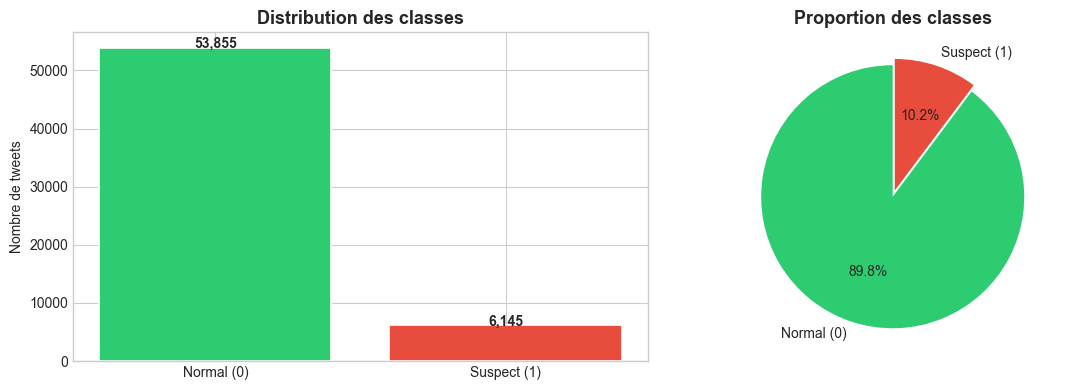

✅ Graphique sauvegardé


In [49]:
class_counts = df[LABEL_COL].value_counts()
class_pct    = df[LABEL_COL].value_counts(normalize=True) * 100

print('=== Distribution des classes ===')
for label, count in class_counts.items():
    pct = class_pct[label]
    name = 'Suspect' if label == 1 else 'Normal'
    print(f"  Classe {label} ({name}) : {count:,} tweets  ({pct:.1f}%)")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(
    ['Normal (0)', 'Suspect (1)'],
    class_counts.values,
    color=colors, edgecolor='white', linewidth=1.2
)
axes[0].set_title('Distribution des classes', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Nombre de tweets')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 50, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(
    class_counts.values,
    labels=['Normal (0)', 'Suspect (1)'],
    autopct='%1.1f%%',
    colors=colors,
    startangle=90,
    explode=(0, 0.05)
)
axes[1].set_title('Proportion des classes', fontsize=13, fontweight='bold')


import os
os.chdir(r'C:\Users\user\Desktop\Mon projet de Detection de suspect')
print(f'✅ Dossier de travail : {os.getcwd()}')

plt.tight_layout()
plt.savefig('reports/figures/distribution_classes.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Graphique sauvegardé')

## 6. Analyse de la longueur des tweets

In [51]:
df['tweet_length']   = df[TEXT_COL].apply(len)
df['word_count']     = df[TEXT_COL].apply(lambda x: len(x.split()))
df['unique_words']   = df[TEXT_COL].apply(lambda x: len(set(x.lower().split())))
df['has_url']        = df[TEXT_COL].apply(lambda x: int(bool(re.search(r'http\S+', x))))
df['has_mention']    = df[TEXT_COL].apply(lambda x: int(bool(re.search(r'@\w+', x))))
df['has_hashtag']    = df[TEXT_COL].apply(lambda x: int(bool(re.search(r'#\w+', x))))
df['exclamation_ct'] = df[TEXT_COL].apply(lambda x: x.count('!'))

print(df[['tweet_length', 'word_count', 'unique_words']].describe().round(1))

       tweet_length  word_count  unique_words
count       60000.0     60000.0       60000.0
mean           73.7        13.1          12.5
std            36.1         6.9           6.3
min             6.0         1.0           1.0
25%            44.0         7.0           7.0
50%            69.0        12.0          12.0
75%           103.0        18.0          17.0
max           186.0        34.0          31.0


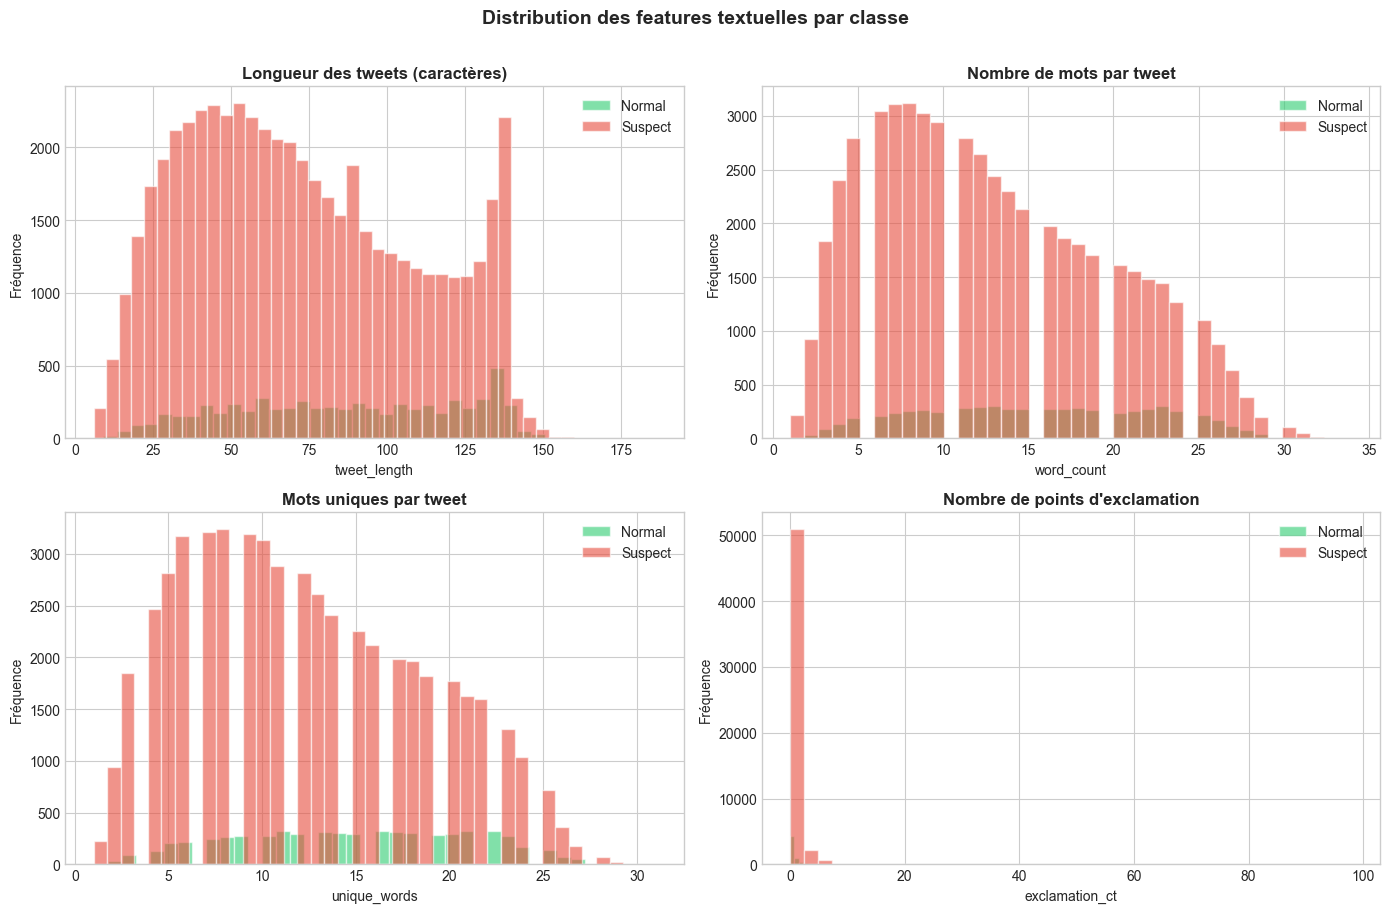

In [52]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for ax, (col, title) in zip(axes.flat, [
    ('tweet_length', 'Longueur des tweets (caractères)'),
    ('word_count',   'Nombre de mots par tweet'),
    ('unique_words', 'Mots uniques par tweet'),
    ('exclamation_ct','Nombre de points d\'exclamation'),
]):
    for label, color, name in zip([0, 1], ['#2ecc71', '#e74c3c'], ['Normal', 'Suspect']):
        subset = df[df[LABEL_COL] == label][col]
        ax.hist(subset, bins=40, alpha=0.6, color=color, label=name, edgecolor='white')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Fréquence')
    ax.legend()

plt.suptitle('Distribution des features textuelles par classe', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('reports/figures/features_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

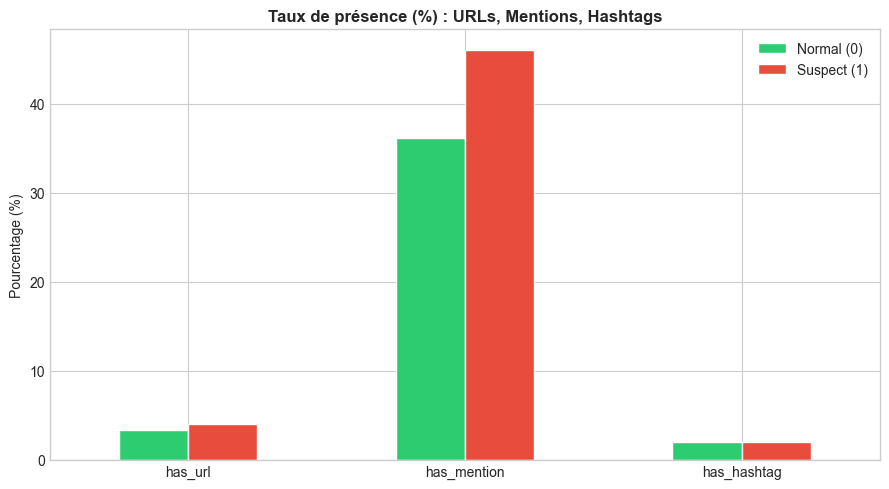

In [53]:
# Taux de présence d'URLs, mentions et hashtags par classe
binary_features = ['has_url', 'has_mention', 'has_hashtag']
grouped = df.groupby(LABEL_COL)[binary_features].mean() * 100
grouped.index = ['Normal (0)', 'Suspect (1)']

grouped.T.plot(
    kind='bar', figsize=(9, 5),
    color=['#2ecc71', '#e74c3c'],
    edgecolor='white'
)
plt.title('Taux de présence (%) : URLs, Mentions, Hashtags', fontweight='bold')
plt.ylabel('Pourcentage (%)')
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.savefig('reports/figures/binary_features.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Mots les plus fréquents (avant nettoyage)

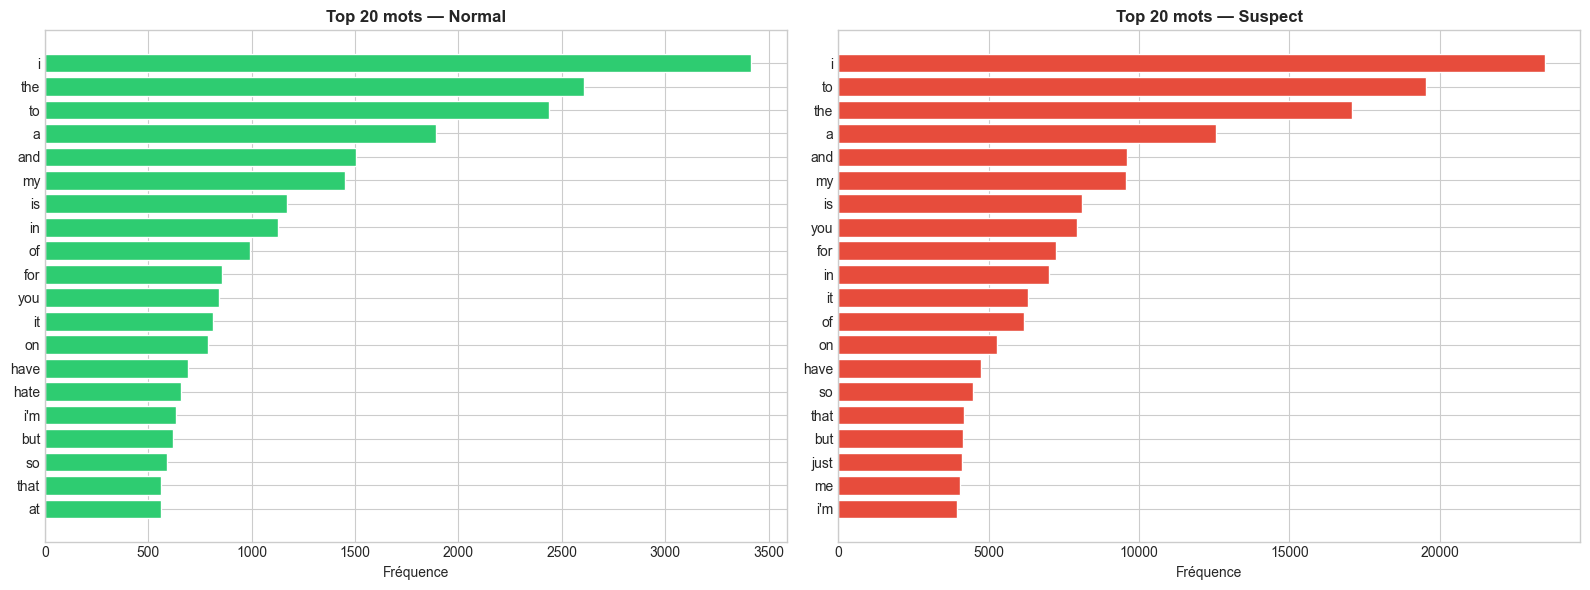

In [54]:
def top_words(series, n=20):
    all_words = ' '.join(series.str.lower()).split()
    return Counter(all_words).most_common(n)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, label, color, name in zip(
    axes, [0, 1], ['#2ecc71', '#e74c3c'], ['Normal', 'Suspect']
):
    words, counts = zip(*top_words(df[df[LABEL_COL] == label][TEXT_COL]))
    ax.barh(list(reversed(words)), list(reversed(counts)), color=color, edgecolor='white')
    ax.set_title(f'Top 20 mots — {name}', fontweight='bold')
    ax.set_xlabel('Fréquence')

plt.tight_layout()
plt.savefig('reports/figures/top_words_brut.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Prétraitement du texte

**Opérations appliquées (dans l'ordre) :**
1. Conversion en minuscules
2. Suppression des URLs
3. Suppression des mentions (`@user`)
4. Suppression des hashtags (le symbole `#`, le mot reste)
5. Suppression des caractères spéciaux et de la ponctuation
6. Suppression des chiffres isolés
7. Suppression des stop words (anglais + français)
8. Lemmatisation (WordNetLemmatizer)
9. Suppression des tokens très courts (< 2 caractères)

> **Choix justifiés :** Les URLs et mentions n'apportent pas d'information sémantique.  
> La lemmatisation est préférée au stemming car elle produit des formes linguistiquement correctes.

In [55]:
# Construction du jeu de stop words
STOP_EN = set(stopwords.words('english'))
STOP_FR = set(stopwords.words('french'))
STOP_WORDS = STOP_EN | STOP_FR

lemmatizer = WordNetLemmatizer()

def clean_tweet(text: str) -> str:
    """Pipeline de nettoyage d'un tweet."""
    # 1. Minuscules
    text = text.lower()
    # 2. Suppression URLs
    text = re.sub(r'http\S+|www\.\S+', '', text)
    # 3. Suppression mentions
    text = re.sub(r'@\w+', '', text)
    # 4. Suppression symbole hashtag (le mot reste)
    text = re.sub(r'#(\w+)', r'\1', text)
    # 5. Suppression caractères spéciaux & ponctuation
    text = re.sub(r'[^\w\s]', ' ', text)
    # 6. Suppression des chiffres
    text = re.sub(r'\b\d+\b', '', text)
    # 7. Tokenisation
    tokens = word_tokenize(text)
    # 8. Suppression stop words + lemmatisation + tokens courts
    tokens = [
        lemmatizer.lemmatize(tok)
        for tok in tokens
        if tok not in STOP_WORDS and len(tok) > 2
    ]
    return ' '.join(tokens)

# Application
df['cleaned_text'] = df[TEXT_COL].apply(clean_tweet)

# Aperçu
print('Exemple de nettoyage :')
for i in range(3):
    print(f'\n[Brut]    {df[TEXT_COL].iloc[i]}')
    print(f'[Nettoyé] {df["cleaned_text"].iloc[i]}')

Exemple de nettoyage :

[Brut]    @switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer.  You shoulda got David Carr of Third Day to do it. ;D
[Nettoyé] awww bummer shoulda got david carr third day

[Brut]    is upset that he can't update his Facebook by texting it... and might cry as a result  School today also. Blah!
[Nettoyé] upset update facebook texting might cry result school today also blah

[Brut]    @Kenichan I dived many times for the ball. Managed to save 50%  The rest go out of bounds
[Nettoyé] dived many time ball managed save rest bound


In [56]:
# Suppression des tweets vides après nettoyage
before = len(df)
df = df[df['cleaned_text'].str.strip() != ''].reset_index(drop=True)
after = len(df)
print(f'Tweets supprimés après nettoyage (trop vides) : {before - after}')
print(f'Dataset final : {after:,} lignes')

Tweets supprimés après nettoyage (trop vides) : 346
Dataset final : 59,654 lignes


## 9. Word Clouds après nettoyage

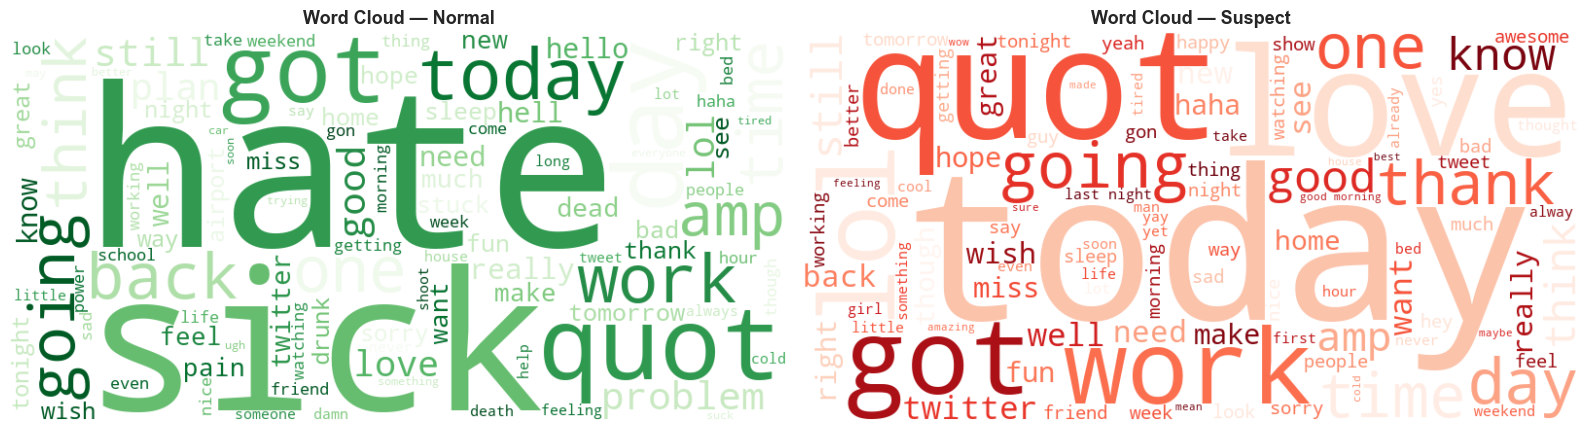

In [57]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, label, colormap, name in zip(
    axes, [0, 1], ['Greens', 'Reds'], ['Normal', 'Suspect']
):
    corpus = ' '.join(df[df[LABEL_COL] == label]['cleaned_text'])
    wc = WordCloud(
        width=800, height=400,
        background_color='white',
        colormap=colormap,
        max_words=100
    ).generate(corpus)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'Word Cloud — {name}', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('reports/figures/wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Top mots après nettoyage

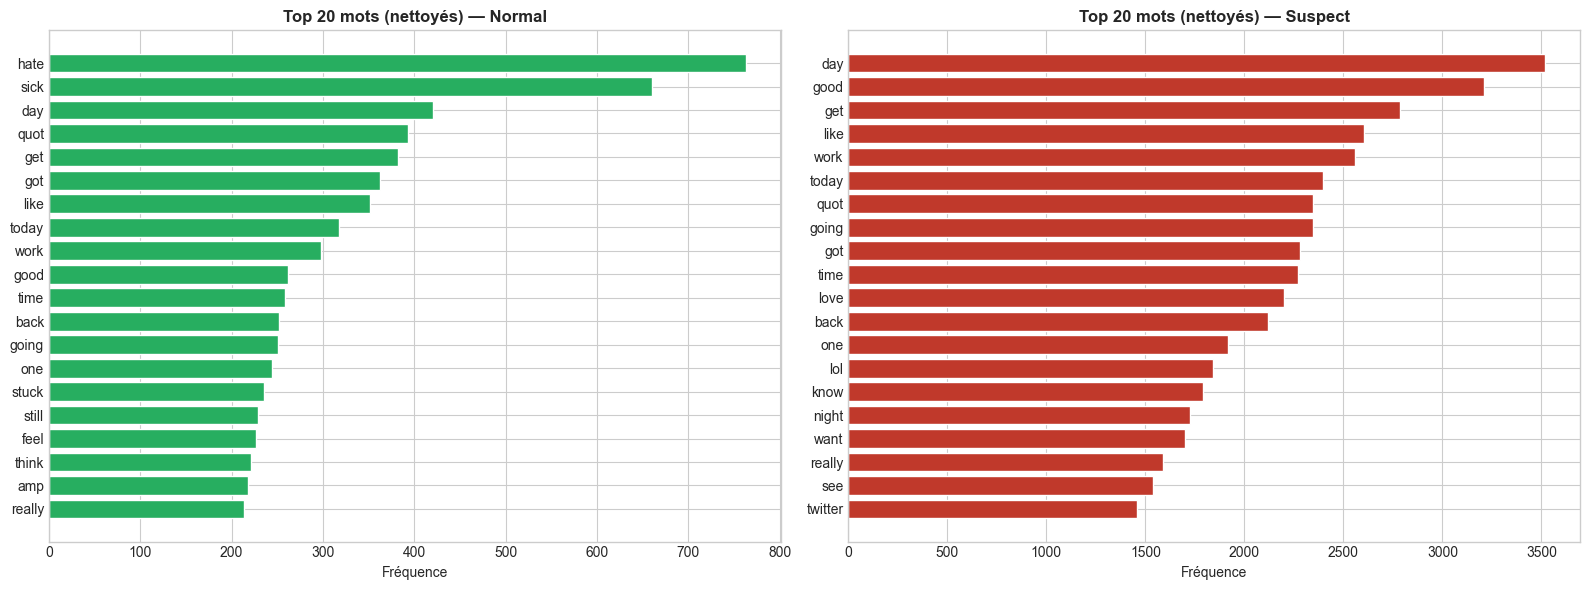

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, label, color, name in zip(
    axes, [0, 1], ['#27ae60', '#c0392b'], ['Normal', 'Suspect']
):
    words, counts = zip(*top_words(df[df[LABEL_COL] == label]['cleaned_text']))
    ax.barh(list(reversed(words)), list(reversed(counts)), color=color, edgecolor='white')
    ax.set_title(f'Top 20 mots (nettoyés) — {name}', fontweight='bold')
    ax.set_xlabel('Fréquence')

plt.tight_layout()
plt.savefig('reports/figures/top_words_clean.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Matrice de corrélation des features numériques

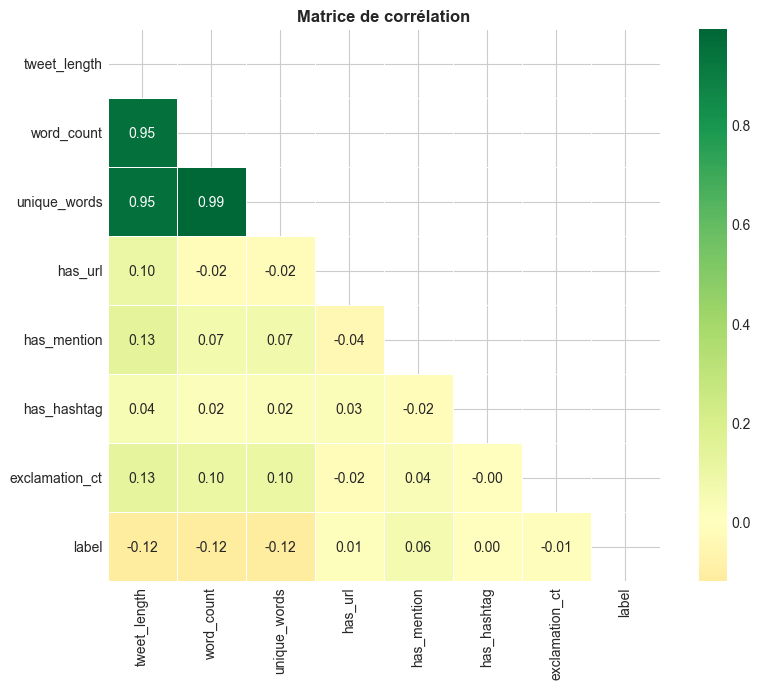

In [59]:
num_features = ['tweet_length', 'word_count', 'unique_words',
                'has_url', 'has_mention', 'has_hashtag', 'exclamation_ct', LABEL_COL]

corr = df[num_features].corr()

plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0,
    square=True, linewidths=0.5
)
plt.title('Matrice de corrélation', fontweight='bold')
plt.tight_layout()
plt.savefig('reports/figures/correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Sauvegarde des données nettoyées

In [60]:
import os
os.makedirs('data/processed', exist_ok=True)
os.makedirs('reports/figures', exist_ok=True)

# Export CSV
df.to_csv('data/processed/tweets_clean.csv', index=False)
print(f'✅ Données nettoyées sauvegardées : data/processed/tweets_clean.csv')
print(f'   Shape : {df.shape}')
print(f'   Colonnes : {df.columns.tolist()}')

✅ Données nettoyées sauvegardées : data/processed/tweets_clean.csv
   Shape : (59654, 10)
   Colonnes : ['message', 'label', 'tweet_length', 'word_count', 'unique_words', 'has_url', 'has_mention', 'has_hashtag', 'exclamation_ct', 'cleaned_text']


## 13. Résumé de l'exploration

| Indicateur | Valeur |
|---|---|
| Nombre total de tweets | À compléter |
| Classe 0 (Normal) | À compléter |
| Classe 1 (Suspect) | À compléter |
| Longueur moyenne (brut) | À compléter |
| Tweets avec URL | À compléter |
| Tweets vides après nettoyage | À compléter |

> **Observation clé :** Si le ratio Normal/Suspect est déséquilibré (> 3:1), il faudra utiliser SMOTE ou des class weights en Partie 4.

---
**Prochaine étape → Partie 2 : Mise en place du pipeline DVC**